# 🧮 Vector Embeddings và Đo lường Độ Tương Đồng Ngữ Nghĩa

## Mục tiêu bài học
- Hiểu khái niệm Vector Embeddings và cách biểu diễn ngữ nghĩa trong không gian vector
- Nắm vững các phương pháp đo lường độ tương đồng:
  - Cosine Similarity
  - Euclidean Distance
  - Dot Product
- Áp dụng vào bài toán thực tế với văn bản tiếng Việt và tiếng Anh
- So sánh ưu nhược điểm của từng phương pháp

## 📚 Phần 1: Giới thiệu về Vector Embeddings

### Vector Embeddings là gì?
**Vector Embeddings** là cách biểu diễn dữ liệu (văn bản, hình ảnh, âm thanh...) dưới dạng các vector số trong không gian nhiều chiều. Trong xử lý ngôn ngữ tự nhiên, embeddings giúp chuyển đổi từ, câu, đoạn văn thành các vector sao cho:

- **Các từ/câu có nghĩa giống nhau** → vectors gần nhau trong không gian
- **Các từ/câu khác nghĩa** → vectors xa nhau trong không gian

### Tại sao cần Embeddings?
1. **Máy tính không hiểu văn bản**, chỉ hiểu số
2. **Capture ngữ nghĩa**: "king" - "man" + "woman" ≈ "queen"
3. **Cho phép tính toán độ tương đồng** giữa các văn bản
4. **Nền tảng cho các ứng dụng AI**: Search, Recommendation, RAG, Classification...

### Ví dụ trực quan:
```
"dog" → [0.2, 0.8, 0.1, ...]  (384 chiều)
"cat" → [0.3, 0.7, 0.2, ...]  (gần với dog)
"car" → [-0.5, 0.1, 0.9, ...] (xa với dog, cat)
```

## 🛠️ Phần 2: Cài đặt và Chuẩn bị

In [1]:
# Cài đặt các thư viện cần thiết
!pip install sentence-transformers numpy matplotlib scikit-learn pandas

  Using cached matplotlib-3.10.8-cp311-cp311-win_amd64.whl.metadata (52 kB)
  Using cached torch-2.10.0-cp311-cp311-win_amd64.whl.metadata (31 kB)
     ---------------------------------------- 0.0/61.0 kB ? eta -:--:--
     ---------------------------------------- 61.0/61.0 kB 1.6 MB/s eta 0:00:00
  Using cached tqdm-4.67.1-py3-none-any.whl.metadata (57 kB)
  Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.61.1-cp311-cp311-win_amd64.whl.metadata (116 kB)
  Using cached kiwisolver-1.4.9-cp311-cp311-win_amd64.whl.metadata (6.4 kB)
  Using cached pillow-12.1.0-cp311-cp311-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached filelock-3.20.3-py3-none-any.whl.metadata (2.1 kB)
  Using cached fsspec-2026.1.0-py3-none-any.whl.metadata (10 kB)
  Using ca


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Import thư viện
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

d:\bt-GenAI\Tokenize\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Load Pre-trained Embedding Model

Chúng ta sẽ sử dụng **sentence-transformers**, một thư viện mạnh mẽ cho embeddings:
- Model: `paraphrase-multilingual-MiniLM-L12-v2` - hỗ trợ 50+ ngôn ngữ, bao gồm tiếng Việt
- Kích thước vector: 384 chiều
- Nhanh và hiệu quả cho hầu hết các ứng dụng

In [3]:
# Load model đa ngôn ngữ
model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
print(f"✅ Model loaded successfully!")
print(f"📊 Embedding dimension: {model.get_sentence_embedding_dimension()}")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 834.23it/s, Materializing param=pooler.dense.weight]                               
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Model loaded successfully!
📊 Embedding dimension: 384


## 🔬 Phần 3: Tạo Vector Embeddings

### 3.1 Embeddings cho từ và câu đơn giản

In [12]:
# Tạo embeddings cho các câu tiếng Anh
sentences_en = [
    "I love programming",
    "I enjoy coding",
    "The weather is nice today",
    "Machine learning is fascinating",
    "Deep learning is a subset of AI"
]

# Tạo embeddings
embeddings_en = model.encode(sentences_en)

print("=" * 70)
print("EMBEDDINGS TIẾNG ANH")
print("=" * 70)
for i, sentence in enumerate(sentences_en):
    print(f"\nCâu {i+1}: {sentence}")
    print(f"First 10 values: {embeddings_en[i][:10]}")
    print(f"Vector norm: {np.linalg.norm(embeddings_en[i]):.4f}")

EMBEDDINGS TIẾNG ANH

Câu 1: I love programming
First 10 values: [-0.01864726  0.16655901 -0.00549031  0.00308917 -0.36515817 -0.24243708
  0.42111245  0.10669716  0.08927006  0.02961418]
Vector norm: 4.2690

Câu 2: I enjoy coding
First 10 values: [ 0.01178808  0.06549587  0.02742379  0.06266233 -0.3437507  -0.2710659
  0.4027277   0.03295499  0.1392394   0.05968473]
Vector norm: 4.4272

Câu 3: The weather is nice today
First 10 values: [-0.04480493  0.35202867  0.00876809  0.19143806 -0.06047342 -0.2098016
  0.27359372  0.03164412 -0.01871067  0.06626955]
Vector norm: 4.5895

Câu 4: Machine learning is fascinating
First 10 values: [-0.169217    0.03204025 -0.16148336 -0.14485246 -0.27510253 -0.30884764
  0.27060288  0.0312994  -0.2055947   0.0712176 ]
Vector norm: 3.3766

Câu 5: Deep learning is a subset of AI
First 10 values: [-0.0336987   0.06020565 -0.0450423   0.05761667 -0.267237   -0.23932654
  0.15881859 -0.18417756 -0.0769981  -0.02884492]
Vector norm: 3.7366


In [13]:
# Tạo embeddings cho các câu tiếng Việt
sentences_vi = [
    "Tôi yêu lập trình",
    "Tôi thích viết code",
    "Hôm nay thời tiết đẹp",
    "Học máy rất hấp dẫn",
    "Học sâu là một phần của AI"
]

embeddings_vi = model.encode(sentences_vi)

print("=" * 70)
print("EMBEDDINGS TIẾNG VIỆT")
print("=" * 70)
for i, sentence in enumerate(sentences_vi):
    print(f"\nCâu {i+1}: {sentence}")
    print(f"First 10 values: {embeddings_vi[i][:10]}")
    print(f"Vector norm: {np.linalg.norm(embeddings_vi[i]):.4f}")

EMBEDDINGS TIẾNG VIỆT

Câu 1: Tôi yêu lập trình
First 10 values: [-0.075303    0.04626438 -0.02472326  0.02352159 -0.37955198 -0.17767237
  0.31471893  0.14991693  0.16120149  0.06134453]
Vector norm: 3.5849

Câu 2: Tôi thích viết code
First 10 values: [-0.09226795  0.06693625 -0.32328966 -0.13070191 -0.2620339  -0.04802443
  0.06542933  0.08910932 -0.05534301  0.18100159]
Vector norm: 3.6425

Câu 3: Hôm nay thời tiết đẹp
First 10 values: [ 0.15501285  0.25530383  0.03599243 -0.06592956 -0.37851045 -0.11839836
  0.2175422   0.22812256 -0.04627054  0.05023238]
Vector norm: 4.9620

Câu 4: Học máy rất hấp dẫn
First 10 values: [ 0.00254175 -0.02505935 -0.1808393  -0.03892576 -0.45883825 -0.14935172
  0.2890493   0.2767208   0.15175703 -0.06403521]
Vector norm: 4.0595

Câu 5: Học sâu là một phần của AI
First 10 values: [ 0.00648856  0.16515297 -0.02012777  0.04519362 -0.4117417  -0.2762395
  0.4381302   0.12934002  0.08363736  0.01565728]
Vector norm: 3.8775


## 📐 Phần 4: Các Phép Đo Độ Tương Đồng

### 4.1 Cosine Similarity (Độ tương đồng Cosine)

**Công thức:**
$$\text{cosine\_similarity}(A, B) = \frac{A \cdot B}{\|A\| \times \|B\|} = \frac{\sum_{i=1}^{n} A_i \times B_i}{\sqrt{\sum_{i=1}^{n} A_i^2} \times \sqrt{\sum_{i=1}^{n} B_i^2}}$$

**Giá trị:**
- Range: [-1, 1]
- 1: Hoàn toàn giống nhau (cùng hướng)
- 0: Không liên quan (vuông góc)
- -1: Hoàn toàn ngược nhau

**Đặc điểm:**
- ✅ Không phụ thuộc vào độ lớn của vector
- ✅ Chỉ quan tâm đến hướng/góc giữa các vector
- ✅ Phổ biến nhất trong NLP và Recommendation Systems
- ❌ Không tính đến magnitude

In [6]:
# Implement Cosine Similarity từ đầu
def cosine_similarity_manual(vec1, vec2):
    """
    Tính cosine similarity giữa 2 vectors
    """
    dot_product = np.dot(vec1, vec2)
    norm_vec1 = np.linalg.norm(vec1)
    norm_vec2 = np.linalg.norm(vec2)
    
    return dot_product / (norm_vec1 * norm_vec2)

# Test với 2 câu đầu tiên (tiếng Anh)
vec1 = embeddings_en[0]  # "I love programming"
vec2 = embeddings_en[1]  # "I enjoy coding"
vec3 = embeddings_en[2]  # "The weather is nice today"

print("=" * 70)
print("COSINE SIMILARITY - TIẾNG ANH")
print("=" * 70)

sim_1_2 = cosine_similarity_manual(vec1, vec2)
sim_1_3 = cosine_similarity_manual(vec1, vec3)

print(f"\n'{sentences_en[0]}' vs '{sentences_en[1]}'")
print(f"Cosine Similarity: {sim_1_2:.4f}")

print(f"\n'{sentences_en[0]}' vs '{sentences_en[2]}'")
print(f"Cosine Similarity: {sim_1_3:.4f}")

print(f"\n💡 Nhận xét: Câu 1 và 2 có ý nghĩa tương tự → similarity cao ({sim_1_2:.4f})")
print(f"💡 Nhận xét: Câu 1 và 3 khác nghĩa → similarity thấp ({sim_1_3:.4f})")

COSINE SIMILARITY - TIẾNG ANH

'I love programming' vs 'I enjoy coding'
Cosine Similarity: 0.9650

'I love programming' vs 'The weather is nice today'
Cosine Similarity: 0.6830

💡 Nhận xét: Câu 1 và 2 có ý nghĩa tương tự → similarity cao (0.9650)
💡 Nhận xét: Câu 1 và 3 khác nghĩa → similarity thấp (0.6830)


### 4.2 Euclidean Distance (Khoảng cách Euclidean)

**Công thức:**
$$\text{euclidean\_distance}(A, B) = \sqrt{\sum_{i=1}^{n} (A_i - B_i)^2}$$

**Giá trị:**
- Range: [0, ∞]
- 0: Hai vector giống hệt nhau
- Càng lớn: Càng khác nhau

**Đặc điểm:**
- ✅ Đơn giản, trực quan
- ✅ Tính đến cả magnitude và direction
- ❌ Phụ thuộc vào độ lớn của vector
- ❌ Nhạy cảm với scale của dữ liệu
- ❌ Không hiệu quả với high-dimensional data (curse of dimensionality)

In [7]:
# Implement Euclidean Distance từ đầu
def euclidean_distance_manual(vec1, vec2):
    """
    Tính Euclidean distance giữa 2 vectors
    """
    return np.sqrt(np.sum((vec1 - vec2) ** 2))

print("=" * 70)
print("EUCLIDEAN DISTANCE - TIẾNG ANH")
print("=" * 70)

dist_1_2 = euclidean_distance_manual(vec1, vec2)
dist_1_3 = euclidean_distance_manual(vec1, vec3)

print(f"\n'{sentences_en[0]}' vs '{sentences_en[1]}'")
print(f"Euclidean Distance: {dist_1_2:.4f}")

print(f"\n'{sentences_en[0]}' vs '{sentences_en[2]}'")
print(f"Euclidean Distance: {dist_1_3:.4f}")

print(f"\n💡 Nhận xét: Câu 1 và 2 tương tự → distance nhỏ ({dist_1_2:.4f})")
print(f"💡 Nhận xét: Câu 1 và 3 khác nhau → distance lớn ({dist_1_3:.4f})")

EUCLIDEAN DISTANCE - TIẾNG ANH

'I love programming' vs 'I enjoy coding'
Euclidean Distance: 1.1610

'I love programming' vs 'The weather is nice today'
Euclidean Distance: 3.5392

💡 Nhận xét: Câu 1 và 2 tương tự → distance nhỏ (1.1610)
💡 Nhận xét: Câu 1 và 3 khác nhau → distance lớn (3.5392)


### 4.3 Dot Product (Tích vô hướng)

**Công thức:**
$$\text{dot\_product}(A, B) = \sum_{i=1}^{n} A_i \times B_i = A_1 \times B_1 + A_2 \times B_2 + ... + A_n \times B_n$$

**Giá trị:**
- Range: (-∞, ∞)
- Càng lớn: Càng tương đồng
- Giá trị âm: Vectors ngược hướng

**Đặc điểm:**
- ✅ Tính toán đơn giản, nhanh nhất
- ✅ Tính đến cả magnitude và direction
- ✅ Hiệu quả cho normalized vectors
- ❌ Phụ thuộc vào độ lớn của vector
- ❌ Khó so sánh giữa các cặp vectors khác nhau

**Lưu ý:** Nếu vectors được normalize (unit vectors), dot product = cosine similarity!

In [8]:
# Implement Dot Product từ đầu
def dot_product_manual(vec1, vec2):
    """
    Tính dot product giữa 2 vectors
    """
    return np.dot(vec1, vec2)

print("=" * 70)
print("DOT PRODUCT - TIẾNG ANH")
print("=" * 70)

dp_1_2 = dot_product_manual(vec1, vec2)
dp_1_3 = dot_product_manual(vec1, vec3)

print(f"\n'{sentences_en[0]}' vs '{sentences_en[1]}'")
print(f"Dot Product: {dp_1_2:.4f}")

print(f"\n'{sentences_en[0]}' vs '{sentences_en[2]}'")
print(f"Dot Product: {dp_1_3:.4f}")

print(f"\n💡 Nhận xét: Câu 1 và 2 tương tự → dot product cao ({dp_1_2:.4f})")
print(f"💡 Nhận xét: Câu 1 và 3 khác nhau → dot product thấp hơn ({dp_1_3:.4f})")

DOT PRODUCT - TIẾNG ANH

'I love programming' vs 'I enjoy coding'
Dot Product: 18.2384

'I love programming' vs 'The weather is nice today'
Dot Product: 13.3807

💡 Nhận xét: Câu 1 và 2 tương tự → dot product cao (18.2384)
💡 Nhận xét: Câu 1 và 3 khác nhau → dot product thấp hơn (13.3807)


## 📊 Phần 5: So sánh Toàn Diện


### 5.2 Visualization - Heatmap

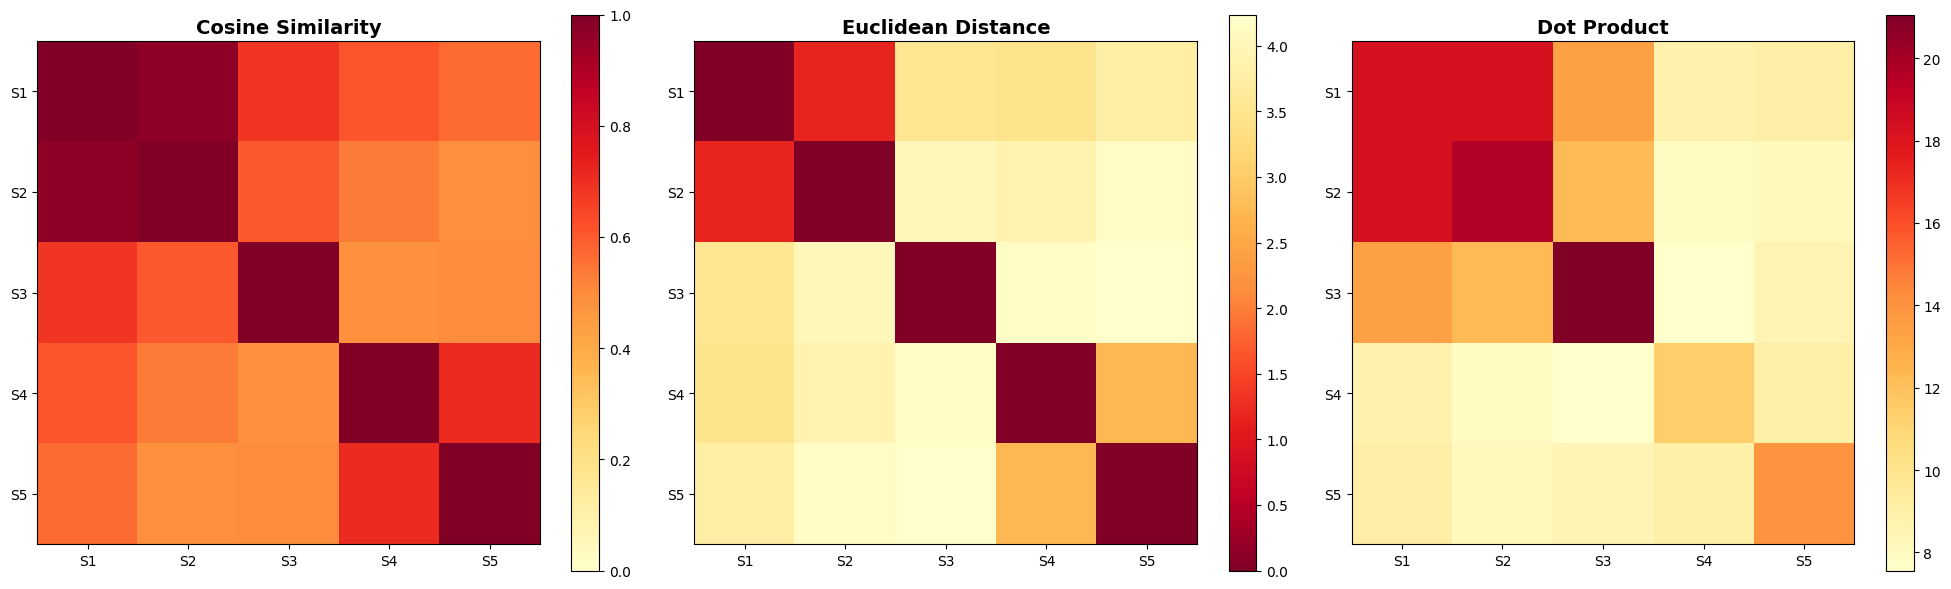


Legend:
S1: I love programming
S2: I enjoy coding
S3: The weather is nice today
S4: Machine learning is fascinating
S5: Deep learning is a subset of AI


In [11]:
# Vẽ heatmap cho 3 phương pháp
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Cosine Similarity
im1 = axes[0].imshow(cos_sim, cmap='YlOrRd', vmin=0, vmax=1)
axes[0].set_title('Cosine Similarity', fontsize=14, fontweight='bold')
axes[0].set_xticks(range(len(sentences_en)))
axes[0].set_yticks(range(len(sentences_en)))
axes[0].set_xticklabels([f'S{i+1}' for i in range(len(sentences_en))])
axes[0].set_yticklabels([f'S{i+1}' for i in range(len(sentences_en))])
plt.colorbar(im1, ax=axes[0])

# Euclidean Distance
im2 = axes[1].imshow(eucl_dist, cmap='YlOrRd_r', vmin=0)
axes[1].set_title('Euclidean Distance', fontsize=14, fontweight='bold')
axes[1].set_xticks(range(len(sentences_en)))
axes[1].set_yticks(range(len(sentences_en)))
axes[1].set_xticklabels([f'S{i+1}' for i in range(len(sentences_en))])
axes[1].set_yticklabels([f'S{i+1}' for i in range(len(sentences_en))])
plt.colorbar(im2, ax=axes[1])

# Dot Product
im3 = axes[2].imshow(dot_prod, cmap='YlOrRd')
axes[2].set_title('Dot Product', fontsize=14, fontweight='bold')
axes[2].set_xticks(range(len(sentences_en)))
axes[2].set_yticks(range(len(sentences_en)))
axes[2].set_xticklabels([f'S{i+1}' for i in range(len(sentences_en))])
axes[2].set_yticklabels([f'S{i+1}' for i in range(len(sentences_en))])
plt.colorbar(im3, ax=axes[2])

plt.tight_layout()
plt.show()

# In legend
print("\nLegend:")
for i, sent in enumerate(sentences_en):
    print(f"S{i+1}: {sent}")

### 5.3 So sánh tiếng Việt và tiếng Anh

In [14]:
# So sánh cross-language: "I love programming" (EN) vs "Tôi yêu lập trình" (VI)
vec_en = embeddings_en[0]
vec_vi = embeddings_vi[0]

cos_sim_cross = cosine_similarity_manual(vec_en, vec_vi)
eucl_dist_cross = euclidean_distance_manual(vec_en, vec_vi)
dot_prod_cross = dot_product_manual(vec_en, vec_vi)

print("=" * 70)
print("SO SÁNH CROSS-LANGUAGE: TIẾNG ANH vs TIẾNG VIỆT")
print("=" * 70)
print(f"\nEnglish: '{sentences_en[0]}'")
print(f"Vietnamese: '{sentences_vi[0]}'")
print(f"\n📊 Kết quả:")
print(f"   - Cosine Similarity: {cos_sim_cross:.4f}")
print(f"   - Euclidean Distance: {eucl_dist_cross:.4f}")
print(f"   - Dot Product: {dot_prod_cross:.4f}")
print(f"\n💡 Model multilingual nhận ra được nghĩa tương tự giữa 2 ngôn ngữ!")

SO SÁNH CROSS-LANGUAGE: TIẾNG ANH vs TIẾNG VIỆT

English: 'I love programming'
Vietnamese: 'Tôi yêu lập trình'

📊 Kết quả:
   - Cosine Similarity: 0.8762
   - Euclidean Distance: 2.0633
   - Dot Product: 13.4091

💡 Model multilingual nhận ra được nghĩa tương tự giữa 2 ngôn ngữ!


## 🎨 Phần 6: Visualization trong không gian 2D

Embeddings có 384 chiều rất khó visualize. Chúng ta sẽ dùng PCA để giảm xuống 2D.

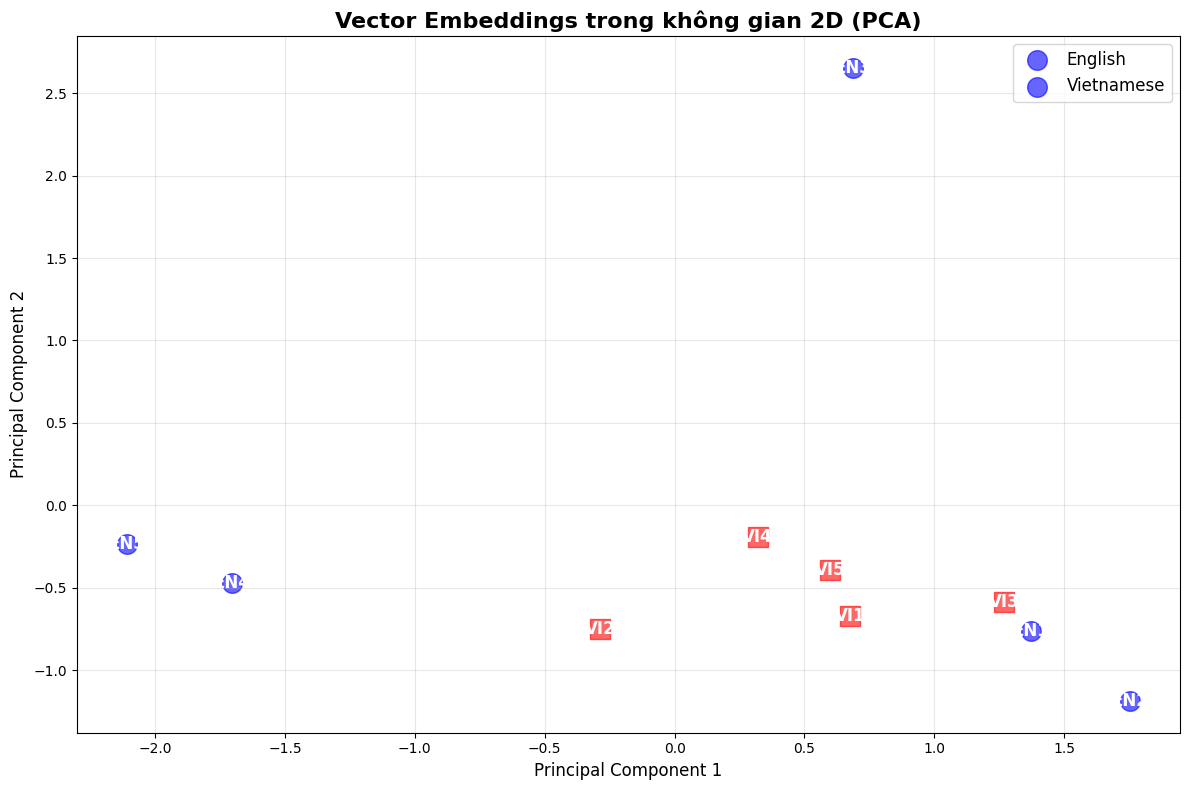


English Sentences:
EN1: I love programming
EN2: I enjoy coding
EN3: The weather is nice today
EN4: Machine learning is fascinating
EN5: Deep learning is a subset of AI

Vietnamese Sentences:
VI1: Tôi yêu lập trình
VI2: Tôi thích viết code
VI3: Hôm nay thời tiết đẹp
VI4: Học máy rất hấp dẫn
VI5: Học sâu là một phần của AI


In [15]:
# Giảm chiều xuống 2D bằng PCA
pca = PCA(n_components=2)
embeddings_2d_en = pca.fit_transform(embeddings_en)
embeddings_2d_vi = pca.transform(embeddings_vi)

# Vẽ scatter plot
plt.figure(figsize=(12, 8))

# Plot English sentences
for i, txt in enumerate(sentences_en):
    plt.scatter(embeddings_2d_en[i, 0], embeddings_2d_en[i, 1], 
                c='blue', s=200, alpha=0.6, marker='o')
    plt.annotate(f'EN{i+1}', (embeddings_2d_en[i, 0], embeddings_2d_en[i, 1]), 
                 fontsize=12, ha='center', va='center', color='white', fontweight='bold')

# Plot Vietnamese sentences
for i, txt in enumerate(sentences_vi):
    plt.scatter(embeddings_2d_vi[i, 0], embeddings_2d_vi[i, 1], 
                c='red', s=200, alpha=0.6, marker='s')
    plt.annotate(f'VI{i+1}', (embeddings_2d_vi[i, 0], embeddings_2d_vi[i, 1]), 
                 fontsize=12, ha='center', va='center', color='white', fontweight='bold')

plt.title('Vector Embeddings trong không gian 2D (PCA)', fontsize=16, fontweight='bold')
plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(['English', 'Vietnamese'], loc='best', fontsize=12)
plt.tight_layout()
plt.show()

# Print legend
print("\nEnglish Sentences:")
for i, sent in enumerate(sentences_en):
    print(f"EN{i+1}: {sent}")

print("\nVietnamese Sentences:")
for i, sent in enumerate(sentences_vi):
    print(f"VI{i+1}: {sent}")

## 🎯 Phần 7: Ứng dụng Thực Tế - Semantic Search

Tìm câu trả lời phù hợp nhất cho câu hỏi của người dùng.

In [16]:
# Knowledge base (cơ sở tri thức)
knowledge_base = [
    "Python là ngôn ngữ lập trình phổ biến cho AI và Machine Learning",
    "TensorFlow là framework deep learning của Google",
    "PyTorch được phát triển bởi Meta (Facebook)",
    "Jupyter Notebook là công cụ tuyệt vời để phân tích dữ liệu",
    "Pandas giúp xử lý và phân tích dữ liệu dễ dàng",
    "NumPy là thư viện cơ bản cho tính toán khoa học",
    "Matplotlib dùng để vẽ biểu đồ và visualization",
    "Scikit-learn cung cấp các thuật toán machine learning",
]

# Tạo embeddings cho knowledge base
kb_embeddings = model.encode(knowledge_base)

def semantic_search(query, knowledge_base, kb_embeddings, top_k=3, method='cosine'):
    """
    Tìm kiếm semantic trong knowledge base
    
    Args:
        query: Câu hỏi của người dùng
        knowledge_base: Danh sách các câu trong knowledge base
        kb_embeddings: Embeddings của knowledge base
        top_k: Số kết quả trả về
        method: Phương pháp đo độ tương đồng ('cosine', 'euclidean', 'dot')
    
    Returns:
        List of (index, score, text) tuples
    """
    # Tạo embedding cho query
    query_embedding = model.encode([query])[0]
    
    # Tính độ tương đồng
    if method == 'cosine':
        scores = [cosine_similarity_manual(query_embedding, kb_emb) for kb_emb in kb_embeddings]
        reverse = True  # Cosine: càng cao càng tốt
    elif method == 'euclidean':
        scores = [euclidean_distance_manual(query_embedding, kb_emb) for kb_emb in kb_embeddings]
        reverse = False  # Euclidean: càng thấp càng tốt
    elif method == 'dot':
        scores = [dot_product_manual(query_embedding, kb_emb) for kb_emb in kb_embeddings]
        reverse = True  # Dot product: càng cao càng tốt
    else:
        raise ValueError(f"Unknown method: {method}")
    
    # Sắp xếp và lấy top_k
    indexed_scores = list(enumerate(scores))
    indexed_scores.sort(key=lambda x: x[1], reverse=reverse)
    
    results = []
    for idx, score in indexed_scores[:top_k]:
        results.append((idx, score, knowledge_base[idx]))
    
    return results

# Test semantic search
query = "Framework nào tốt cho deep learning?"

print("=" * 70)
print("SEMANTIC SEARCH")
print("=" * 70)
print(f"\n❓ Query: {query}\n")

for method in ['cosine', 'euclidean', 'dot']:
    print(f"\n{'='*70}")
    print(f"Phương pháp: {method.upper()}")
    print(f"{'='*70}")
    
    results = semantic_search(query, knowledge_base, kb_embeddings, top_k=3, method=method)
    
    for rank, (idx, score, text) in enumerate(results, 1):
        print(f"\nTop {rank}: (Score: {score:.4f})")
        print(f"   {text}")

SEMANTIC SEARCH

❓ Query: Framework nào tốt cho deep learning?


Phương pháp: COSINE

Top 1: (Score: 0.7982)
   TensorFlow là framework deep learning của Google

Top 2: (Score: 0.7821)
   Python là ngôn ngữ lập trình phổ biến cho AI và Machine Learning

Top 3: (Score: 0.7536)
   Scikit-learn cung cấp các thuật toán machine learning

Phương pháp: EUCLIDEAN

Top 1: (Score: 2.4406)
   TensorFlow là framework deep learning của Google

Top 2: (Score: 2.7010)
   Python là ngôn ngữ lập trình phổ biến cho AI và Machine Learning

Top 3: (Score: 2.7981)
   Scikit-learn cung cấp các thuật toán machine learning

Phương pháp: DOT

Top 1: (Score: 12.3869)
   Jupyter Notebook là công cụ tuyệt vời để phân tích dữ liệu

Top 2: (Score: 12.1898)
   Python là ngôn ngữ lập trình phổ biến cho AI và Machine Learning

Top 3: (Score: 11.5795)
   Pandas giúp xử lý và phân tích dữ liệu dễ dàng


## 📋 Phần 8: Bảng So Sánh Tổng Quan

| Tiêu chí | Cosine Similarity | Euclidean Distance | Dot Product |
|----------|-------------------|-----------------------|-------------|
| **Range** | [-1, 1] | [0, ∞] | (-∞, ∞) |
| **Tốt nhất khi** | 1 | 0 | Càng lớn càng tốt |
| **Phụ thuộc magnitude** | ❌ Không | ✅ Có | ✅ Có |
| **Tốc độ tính toán** | Trung bình | Trung bình | Nhanh nhất |
| **Ứng dụng phổ biến** | NLP, Recommendation | Computer Vision, Clustering | Ranking (với normalized vectors) |
| **Ưu điểm** | Không phụ thuộc scale, ổn định | Trực quan, đơn giản | Nhanh, hiệu quả |
| **Nhược điểm** | Tính toán phức tạp hơn | Nhạy cảm với scale | Phụ thuộc magnitude |
| **Khi nào dùng** | So sánh hướng/góc | So sánh khoảng cách thực | Vectors đã normalize |

## 🎯 Phần 9: BÀI TẬP THỰC HÀNH

### Bài tập 1: Tạo embeddings và tính độ tương đồng
Cho 3 câu sau (tiếng Việt hoặc tiếng Anh tùy chọn), hãy:
1. Tạo embeddings
2. Tính độ tương đồng giữa các cặp câu bằng cả 3 phương pháp
3. Phân tích kết quả

In [ ]:
# TODO: Điền 3 câu của bạn vào đây
my_sentences = [
    "Câu 1 của bạn...",
    "Câu 2 của bạn...",
    "Câu 3 của bạn..."
]

# TODO: Tạo embeddings


# TODO: Tính cosine similarity giữa câu 1 và 2


# TODO: Tính euclidean distance giữa câu 1 và 3


# TODO: Tính dot product giữa câu 2 và 3


# TODO: In kết quả và phân tích

### Bài tập 2: So sánh các phương pháp
Viết một hàm so sánh cả 3 phương pháp đo độ tương đồng cho 2 câu bất kỳ và trả về kết quả dưới dạng DataFrame.

In [ ]:
# TODO: Hoàn thiện hàm này
def compare_similarity_methods(sentence1, sentence2, model):
    \"\"\"
    So sánh 3 phương pháp đo độ tương đồng
    
    Returns:
        DataFrame với kết quả của cả 3 phương pháp
    \"\"\"
    # TODO: Tạo embeddings cho 2 câu
    
    
    # TODO: Tính toán với 3 phương pháp
    
    
    # TODO: Tạo DataFrame và return
    results = {
        'Method': ['Cosine Similarity', 'Euclidean Distance', 'Dot Product'],
        'Score': [0.0, 0.0, 0.0],  # Thay bằng giá trị thực
        'Interpretation': ['', '', '']  # Thêm giải thích
    }
    
    return pd.DataFrame(results)

# Test hàm của bạn
sentence1 = "Học máy là một lĩnh vực của AI"
sentence2 = "Machine learning is a field of artificial intelligence"

# TODO: Gọi hàm và in kết quả
# df_result = compare_similarity_methods(sentence1, sentence2, model)
# print(df_result)

### Bài tập 3: Xây dựng hệ thống tìm kiếm câu hỏi-đáp
Tạo một knowledge base về một chủ đề bạn quan tâm (ít nhất 10 câu), sau đó:
1. Tạo embeddings cho tất cả câu
2. Cho người dùng nhập câu hỏi
3. Tìm top 3 câu trả lời phù hợp nhất
4. So sánh kết quả với 3 phương pháp khác nhau

In [ ]:
# TODO: Tạo knowledge base của bạn về một chủ đề (ít nhất 10 câu)
my_knowledge_base = [
    "Câu 1 về chủ đề của bạn...",
    "Câu 2...",
    # Thêm ít nhất 8 câu nữa
]

# TODO: Tạo embeddings cho knowledge base


# TODO: Nhập câu hỏi của người dùng
user_query = "Câu hỏi của bạn..."

# TODO: Tìm kiếm với cả 3 phương pháp và so sánh kết quả
# Sử dụng hàm semantic_search đã được định nghĩa ở trên

### Bài tập 4: Phân tích sự khác biệt giữa normalized và non-normalized vectors
Tạo 2 vectors tùy ý, sau đó:
1. Tính dot product của vectors gốc
2. Normalize cả 2 vectors
3. Tính dot product của vectors đã normalize
4. Tính cosine similarity của vectors gốc
5. So sánh kết quả và giải thích

In [ ]:
# TODO: Tạo 2 vectors tùy ý
vec_a = np.array([1, 2, 3, 4, 5])
vec_b = np.array([2, 4, 6, 8, 10])

print("Vector A:", vec_a)
print("Vector B:", vec_b)

# TODO: Tính dot product của vectors gốc
dot_original = 0  # Thay bằng tính toán thực

# TODO: Normalize vectors
def normalize_vector(vec):
    \"\"\"Normalize vector to unit length\"\"\"
    # TODO: Implement
    return vec

vec_a_norm = normalize_vector(vec_a)
vec_b_norm = normalize_vector(vec_b)

# TODO: Tính dot product của vectors đã normalize
dot_normalized = 0  # Thay bằng tính toán thực

# TODO: Tính cosine similarity của vectors gốc
cos_sim_original = 0  # Thay bằng tính toán thực

# TODO: So sánh và giải thích
print(f"\nDot Product (Original): {dot_original}")
print(f"Dot Product (Normalized): {dot_normalized}")
print(f"Cosine Similarity (Original): {cos_sim_original}")
print(f"\n💡 Nhận xét: ...")

### Bài tập 5: Clustering với Embeddings
Cho 15 câu về 3 chủ đề khác nhau (mỗi chủ đề 5 câu). Hãy:
1. Tạo embeddings cho tất cả câu
2. Visualize trong không gian 2D (dùng PCA)
3. Phân tích xem các câu cùng chủ đề có gần nhau không
4. Thử nghiệm với K-Means clustering

In [ ]:
# TODO: Tạo 15 câu về 3 chủ đề (mỗi chủ đề 5 câu)
# Chủ đề 1: Thể thao
# Chủ đề 2: Công nghệ
# Chủ đề 3: Ẩm thực

sentences_sports = [
    "Bóng đá là môn thể thao phổ biến nhất thế giới",
    # Thêm 4 câu nữa về thể thao
]

sentences_tech = [
    "Trí tuệ nhân tạo đang thay đổi thế giới",
    # Thêm 4 câu nữa về công nghệ
]

sentences_food = [
    "Phở là món ăn truyền thống của Việt Nam",
    # Thêm 4 câu nữa về ẩm thực
]

all_sentences = sentences_sports + sentences_tech + sentences_food
labels = ['Sports']*5 + ['Tech']*5 + ['Food']*5

# TODO: Tạo embeddings


# TODO: Giảm chiều xuống 2D với PCA


# TODO: Visualize với màu sắc khác nhau cho mỗi chủ đề


# TODO: Thử K-Means clustering
from sklearn.cluster import KMeans

# TODO: Implement K-Means với k=3


# TODO: So sánh clusters với labels thực tế

### Bài tập 6: So sánh các Embedding Models
Thử nghiệm với các embedding models khác nhau và so sánh kết quả:
- `paraphrase-multilingual-MiniLM-L12-v2` (đã dùng)
- `all-MiniLM-L6-v2` (English only, faster)
- `paraphrase-multilingual-mpnet-base-v2` (better quality, slower)

In [ ]:
# TODO: Load các models khác nhau
# model1 = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
# model2 = SentenceTransformer('all-MiniLM-L6-v2')
# model3 = SentenceTransformer('paraphrase-multilingual-mpnet-base-v2')

# TODO: Chọn 2 câu để so sánh
sentence_1 = "Artificial intelligence is the future"
sentence_2 = "AI will shape our tomorrow"

# TODO: Tạo embeddings với mỗi model


# TODO: So sánh cosine similarity từ các models khác nhau


# TODO: So sánh tốc độ, chất lượng, kích thước vector

## 📝 Phần 10: Tổng kết

### Những điều cần nhớ:

1. **Vector Embeddings** biểu diễn ngữ nghĩa trong không gian số
   - Câu có nghĩa giống nhau → vectors gần nhau
   - Cho phép tính toán độ tương đồng ngữ nghĩa

2. **Cosine Similarity** - Phổ biến nhất
   - Đo góc giữa 2 vectors
   - Range: [-1, 1]
   - Không phụ thuộc vào magnitude
   - Tốt nhất cho NLP

3. **Euclidean Distance** - Khoảng cách thực
   - Đo khoảng cách trực tiếp
   - Range: [0, ∞]
   - Phụ thuộc magnitude
   - Tốt cho dữ liệu không gian

4. **Dot Product** - Nhanh nhất
   - Tích vô hướng của 2 vectors
   - Range: (-∞, ∞)
   - Tương đương cosine khi vectors đã normalize
   - Tốt cho ranking

5. **Khi nào dùng phương pháp nào?**
   - **Cosine**: So sánh văn bản, recommendation, search
   - **Euclidean**: Clustering, computer vision, spatial data
   - **Dot Product**: Ranking với normalized vectors, neural networks

### Ứng dụng thực tế:
- 🔍 Semantic Search
- 📚 Document Similarity
- 🤖 Chatbots & Q&A Systems
- 🎯 Recommendation Systems
- 📊 Text Clustering & Classification
- 🌐 Cross-lingual Search
- 🔄 Duplicate Detection

## 🔗 Phần 11: Tài nguyên tham khảo

### Thư viện & Models:
- [Sentence Transformers](https://www.sbert.net/)
- [Hugging Face Models](https://huggingface.co/models)
- [OpenAI Embeddings](https://platform.openai.com/docs/guides/embeddings)

### Bài viết & Tutorial:
- [Understanding Vector Embeddings](https://www.pinecone.io/learn/vector-embeddings/)
- [Cosine Similarity Explained](https://www.machinelearningplus.com/nlp/cosine-similarity/)
- [Semantic Search with Embeddings](https://www.sbert.net/examples/applications/semantic-search/README.html)

### Vector Databases:
- Pinecone
- Weaviate
- Milvus
- Qdrant
- ChromaDB

---
**Chúc các bạn học tốt! 🎓**

*Nếu có thắc mắc, hãy thử nghiệm thêm với các ví dụ khác nhau trong các bài tập!*